In [1]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]


In [2]:
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v4.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]

df_env = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env = df_env.drop(['TKN_pct'], axis=1)

df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_btm = df_env.loc[df_sites_qc_btm.index.values,:]

df_env_top_pred = df_env_top.iloc[:,np.append(range(0,21), range(24,32))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_btm_pred = df_env_btm.iloc[:,np.append(range(0,21), range(24,32))]
df_env_btm_pred = df_env_btm.fillna(0.)

In [3]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [4]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(5, 16)
(5, 15)
(5, 15)
(5, 15)
(5, 61)


In [8]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X, y = np.log(datah7[[0,1,2,4,5],:].T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [10]:
df_env_top['Respiratio'].iloc[:,1].to_csv('soils_respiration_top.csv')

In [9]:
np.savetxt(fname='soils_nmf_7.csv',X=datah7,delimiter=',')

In [13]:
#from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,5000),
    "max_depth": randint(5,63),
    #"max_features": ['auto', 'sqrt', 'log2', 2,3,4,5],
    "min_samples_split": randint(2, 10),
    #"criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.1)
}

rsh = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=500,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B672C5DC570),
                   n_iter=500,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b672efe98d0>,
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b672efe9be0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b672efe9278>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b672b10bdd8>},
                   random_state=

Text(0, 0.5, 'predicted')

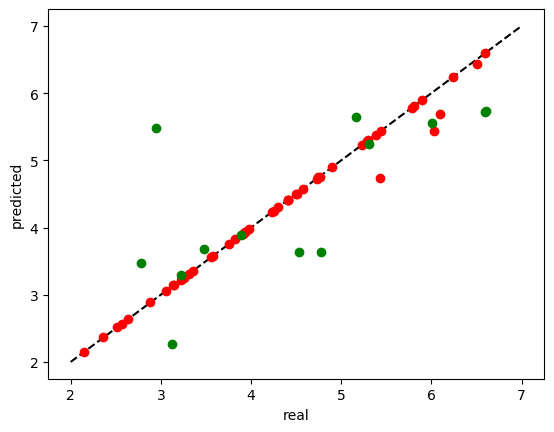

In [14]:
from matplotlib import pyplot as plt
y_hat = rsh.best_estimator_.predict(X_test)

# Plot predicted MPG without error bars
#plt.scatter(y_test, y_hat)
#plt.plot([2, 7], [2, 7], 'k--')
#plt.xlabel('Real respiration')
#plt.ylabel('Predicted respiration')
#plt.show()

plt.plot([2, 7], [2, 7], 'k--')
plt.plot(
    y_train,
    rsh.best_estimator_.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    rsh.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [12]:
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.05963794057787192, learning_rate=1.0,
                          loss='absolute_error', max_depth=16, max_features=3,
                          min_samples_split=8, n_estimators=3583,
                          random_state=RandomState(MT19937) at 0x2B672ABF3BA0)

In [15]:
rsh.best_estimator_.score(X_test,y_test)

0.48120019502784905

In [53]:
rsh.best_estimator_.score(X_test,y_test)

0.5434738831180712

In [56]:
rsh.cv_results_['mean_train_score']

array([            nan, -8.12135667e-01, -1.15212906e+00, -7.58869236e-01,
       -1.47403524e-01, -1.10954909e+00,             nan, -6.58632537e-01,
       -7.27889501e-01, -1.11921899e+00, -4.12854383e-01, -6.63565799e-01,
                   nan,             nan, -3.88621193e-01, -7.58775168e-01,
       -4.39225686e-01,             nan, -3.81977319e-01, -5.46656910e-01,
       -3.60393926e-01, -9.89586219e-01, -5.13303754e-01, -1.75343974e-01,
       -7.92866006e-01,             nan, -7.62631809e-01, -1.13842121e+00,
       -9.35746759e-01, -2.01355727e-01, -1.87220038e-01, -9.90070906e-01,
       -8.21913621e-01, -4.25612429e-01, -1.13896201e+00, -1.10712951e+00,
       -8.03231266e-01, -5.36207416e-02, -6.28996541e-01, -4.90805625e-01,
       -1.06668641e+00, -1.14461946e+00, -1.07806795e+00,             nan,
       -4.20940527e-01, -1.15212906e+00,             nan, -8.24154303e-01,
                   nan, -3.58605052e-02,             nan, -6.63089481e-01,
       -2.82694271e-02,  

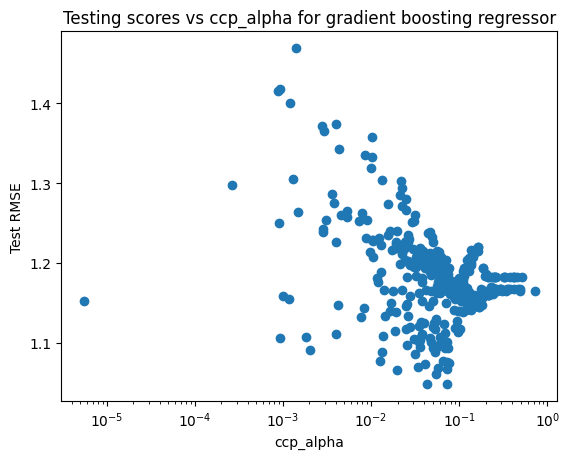

In [54]:
ccp_alphas = rsh.cv_results_["param_ccp_alpha"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("ccp_alpha")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs ccp_alpha for gradient boosting regressor")
plt.show()

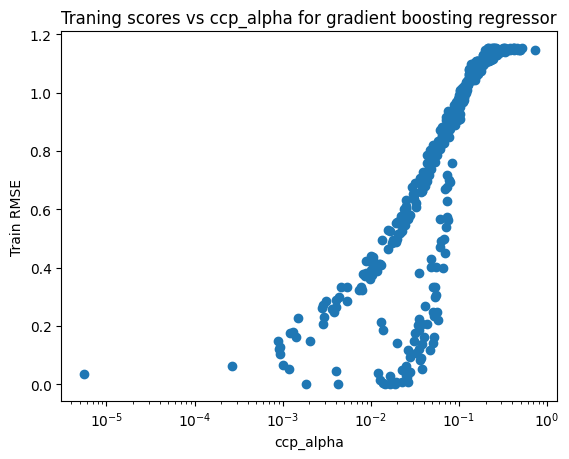

In [63]:
ccp_alphas = rsh.cv_results_["param_ccp_alpha"].data
train_scores = -rsh.cv_results_["mean_train_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, train_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("ccp_alpha")
plt.ylabel("Train RMSE")
plt.title("Traning scores vs ccp_alpha for gradient boosting regressor")
plt.show()

In [16]:
import joblib
joblib.dump(rsh, '/home/shic892/corems/gradient_nmf_12356_log_top_respiration_log.pkl')

['/home/shic892/corems/gradient_nmf_12356_log_top_respiration_log.pkl']

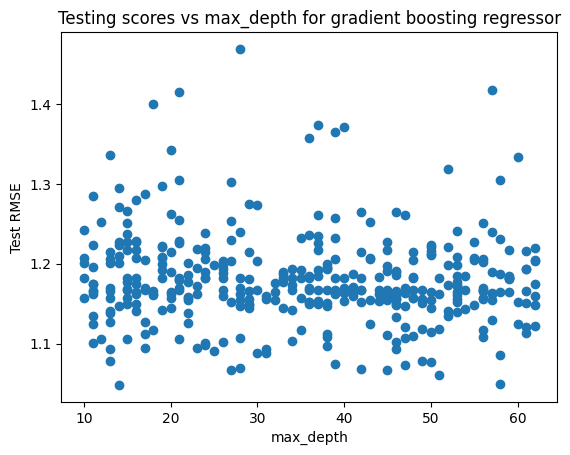

In [55]:

mx_depths = rsh.cv_results_["param_max_depth"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.plot(mx_depths, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("max_depth")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs max_depth for gradient boosting regressor")
plt.show()

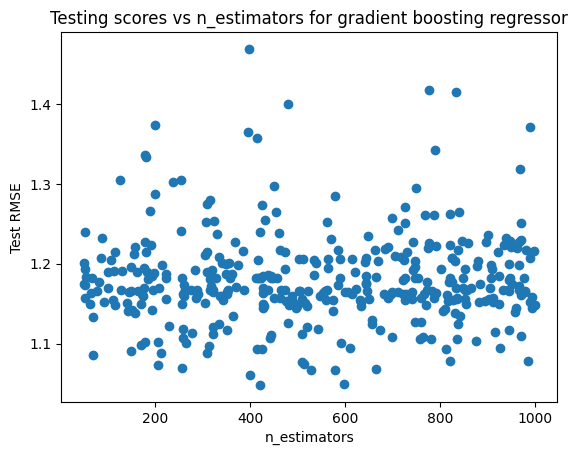

In [57]:

n_trees = rsh.cv_results_["param_n_estimators"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.plot(n_trees, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("n_estimators")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs n_estimators for gradient boosting regressor")
plt.show()

/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 8.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 13.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: User

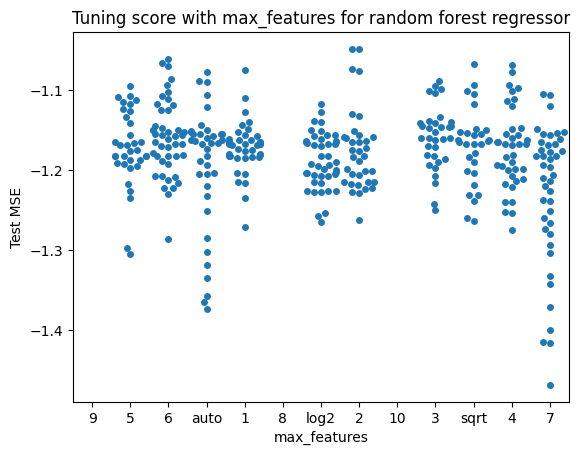

In [58]:
import seaborn as sns 

results_df = pd.DataFrame(rsh.cv_results_)
sns.swarmplot(x="param_max_features", y="mean_test_score", data=results_df)
plt.xlabel("max_features")
plt.ylabel("Test MSE")
plt.title("Tuning score with max_features for random forest regressor")
plt.show()

/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


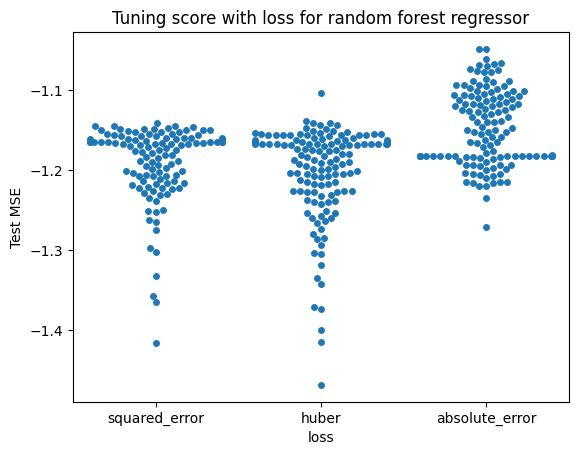

In [59]:

sns.swarmplot(x="param_loss", y="mean_test_score", data=results_df)
plt.xlabel("loss")
plt.ylabel("Test MSE")
plt.title("Tuning score with loss for random forest regressor")
plt.show()


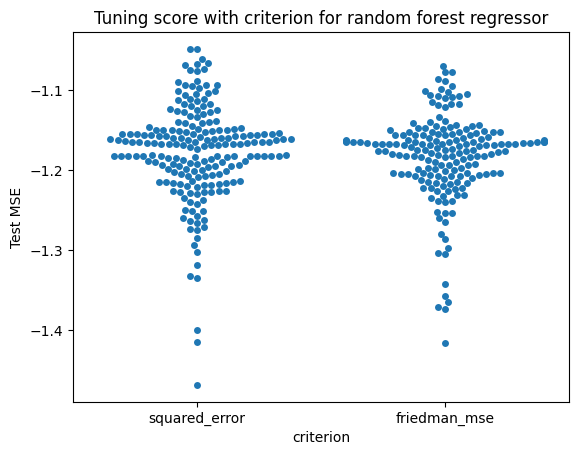

In [60]:
sns.swarmplot(x="param_criterion", y="mean_test_score", data=results_df)
plt.xlabel("criterion")
plt.ylabel("Test MSE")
plt.title("Tuning score with criterion for random forest regressor")
plt.show()

In [62]:
results_df.to_csv('gradientBoosting_NMF_log_top_respirtaion_log_031523.csv')

In [1]:
import joblib
rsh = joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')
rsh.best_score_

-1.048461013941341

In [6]:
rsh.best_estimator_.score(X_test,y_test)

0.5434738831180712

Text(0.5, 1.0, 'Feature Importance (MDI)')

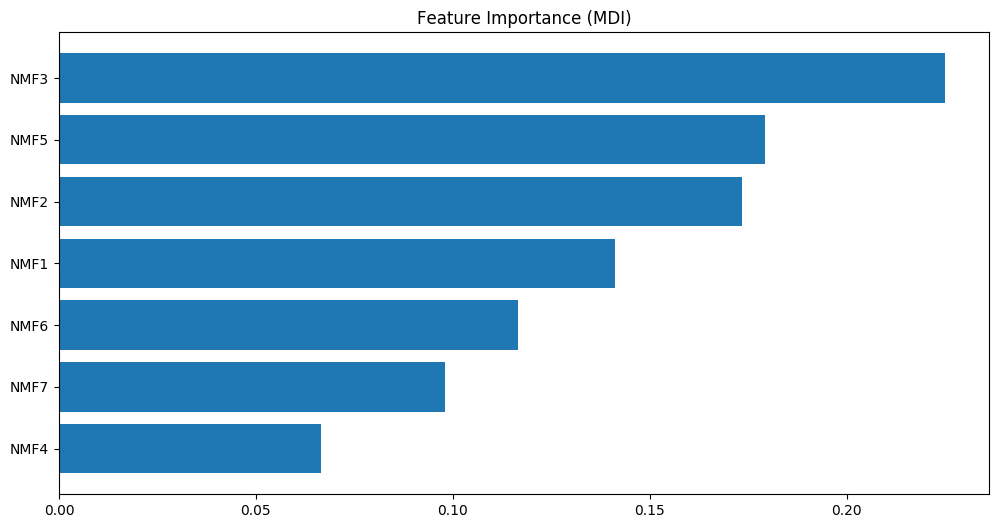

In [3]:
import matplotlib.pyplot as plt
import numpy as np
feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7'])[sorted_idx])
plt.title("Feature Importance (MDI)")

In [11]:

rsh.best_estimator_.feature_importances_


array([0.14126701, 0.17350862, 0.2248853 , 0.06661137, 0.17919332,
       0.1166191 , 0.09791529])

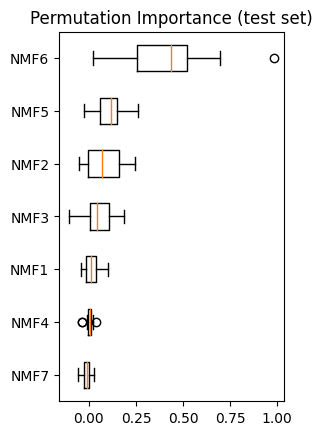

In [10]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh.best_estimator_, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7'])[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

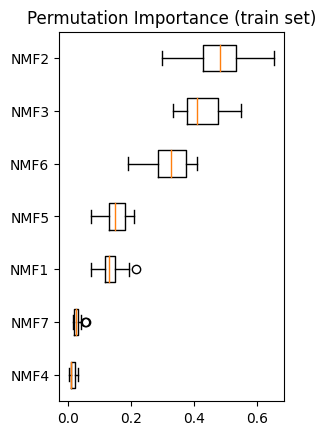

In [13]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh.best_estimator_, X_train, y_train, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7'])[sorted_idx],
)
plt.title("Permutation Importance (train set)")
fig.tight_layout()
plt.show()

In [25]:
#rsh.cv_results_['mean_test_score'][np.where(rsh.cv_results_['rank_test_score']==1)]

rsh.cv_results_['split4_test_score'][np.where(rsh.cv_results_['rank_test_score']==1)]

array([-0.70769253])

In [11]:
from sklearn.metrics import mean_squared_error
y_hat = rsh.best_estimator_.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_hat))

0.8906801637081007

In [12]:
y_hat = rsh.best_estimator_.predict(X_train)
np.sqrt(mean_squared_error(y_train, y_hat))

0.3232417792617265

array([[<AxesSubplot:title={'center':'0'}>]], dtype=object)

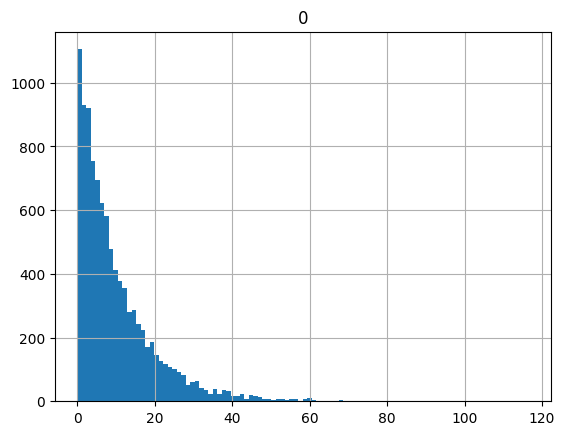

In [14]:
from scipy.stats import expon as expon
pd.DataFrame(expon(scale=10).rvs(10000)).hist(bins=100)

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X, y = np.log(datah5.T+1), np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

In [88]:
#from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, mielke, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    #"loss": ['squared_error','absolute_error'],
    "n_estimators": randint(50,5000),
    "max_depth": randint(2,60),
    #"max_features": ['auto', 'sqrt', 'log2', 2,3,4,5],
    "min_samples_leaf": randint(1,20),
    "min_samples_split": randint(2, 10),
    #"criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [ 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : mielke(s=5, loc=0.005, k=0.1)
}

rsh = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=100,return_train_score=True, 
     cv=4,scoring="neg_root_mean_squared_error", 
)
rsh.fit(X_train, y_train)

RandomizedSearchCV(cv=4,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B9F2A622258),
                   n_iter=100,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b9f2c568b38>,
                                        'learning_rate': [0.001, 0.01, 0.1,
                                                          1.0],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b9f2c559f28>,
                                        'min_sampl...cipy.stats._distn_infrastructure.rv_frozen object at 0x2b9f2c568b00>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b9f2c568cc0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b9f2c3d6e48>},
                   random_state=RandomState(MT19937) at 0x2B

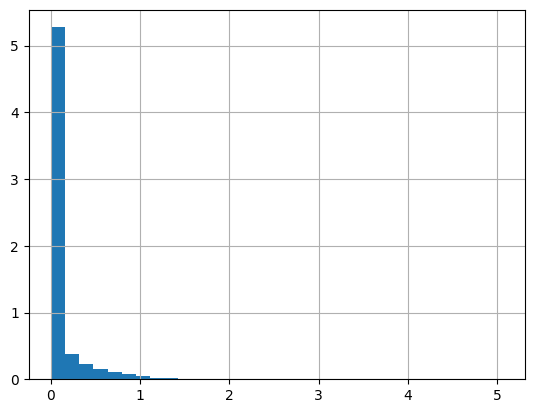

In [87]:
import pandas as pd
import scipy.stats as stats
d = stats.mielke(s=5, loc=0.005, k=0.1)
rv = d.rvs(100000)
pd.Series(rv).hist(bins=32, normed=True)

Text(0, 0.5, 'predicted')

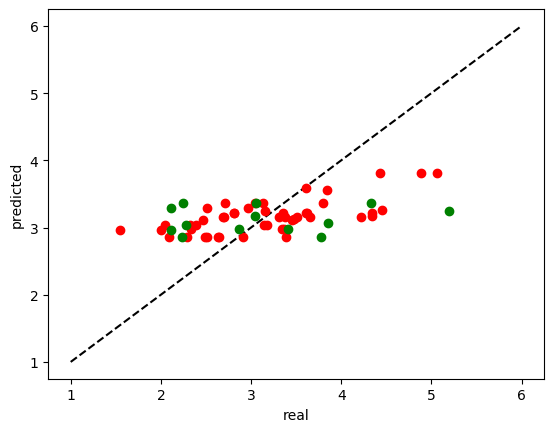

In [89]:
y_hat = rsh.best_estimator_.predict(X_test)

plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    rsh.best_estimator_.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    rsh.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [91]:
from sklearn.metrics import mean_squared_error
y_hat = rsh.best_estimator_.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_hat))

0.9146755936721429

In [92]:
rsh.best_score_

-0.7406437897216817

Text(0, 0.5, 'predicted')

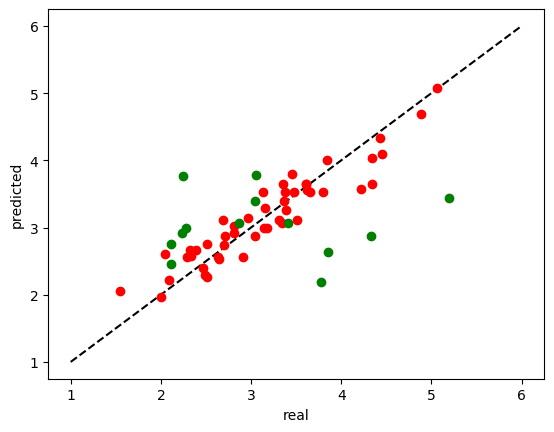

In [58]:
y_hat = rsh.best_estimator_.predict(X_test)

plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    rsh.best_estimator_.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    rsh.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [90]:
rsh.best_estimator_.score(X_test,y_test)

0.02650180098548094

In [67]:
rsh.best_estimator_.score(X_train,y_train)

0.4421623317415574

In [63]:
rsh.best_params_

{'ccp_alpha': 0.003940575717969754,
 'learning_rate': 1.0,
 'max_depth': 43,
 'min_samples_leaf': 5,
 'min_samples_split': 3,
 'n_estimators': 1488}

In [62]:
joblib.dump(rsh, '/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd8_best_train.pkl')

['/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd8_best_train.pkl']

In [93]:
rsh = joblib.load('/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd8_best.pkl')

In [95]:
rsh.best_score_

-0.06571277875904566

In [94]:
y_hat = rsh.best_estimator_.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_hat))

0.8870029646195833

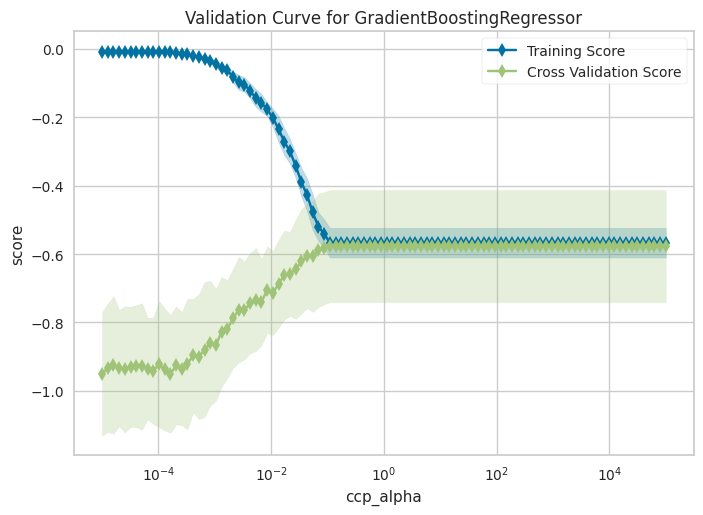

<AxesSubplot:title={'center':'Validation Curve for GradientBoostingRegressor'}, xlabel='ccp_alpha', ylabel='score'>

In [13]:
from yellowbrick.model_selection import ValidationCurve
viz = ValidationCurve(
    GradientBoostingRegressor(), param_name="ccp_alpha",
    param_range=np.logspace(-5, 5,100), cv=5, logx=True,scoring="neg_mean_squared_error"
)

# Fit and show the visualizer
viz.fit(X_train, y_train)
viz.show()

In [68]:
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.012662078050421417, learning_rate=0.01,
                          max_depth=10, min_samples_leaf=2, min_samples_split=5,
                          n_estimators=2724,
                          random_state=RandomState(MT19937) at 0x2B19795AA048)

In [73]:
rsh.best_score_

-0.8123630429396591

In [60]:
rsh.best_estimator_.score(X_test,y_test)

0.10508213457420168

In [64]:
rsh.best_estimator_.score(X_train,y_train)

0.5364972550710971

Text(0, 0.5, 'predicted')

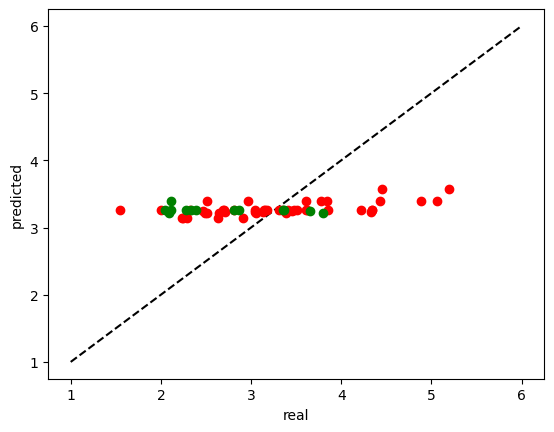

In [80]:
from matplotlib import pyplot as plt


plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    rsh.best_estimator_.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    rsh.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [66]:
import joblib
joblib.dump(rsh, '/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd2.pkl')

['/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd2.pkl']

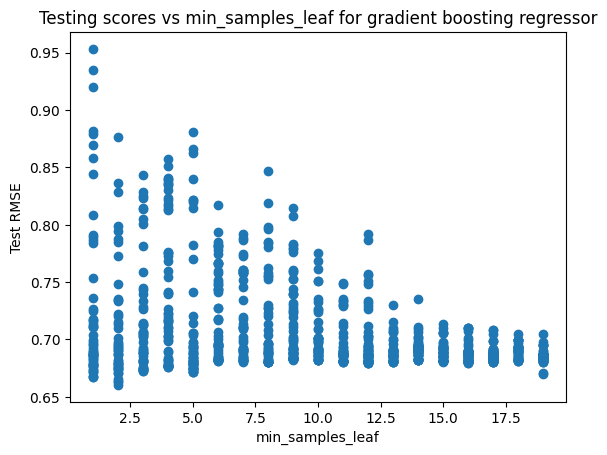

In [52]:
ccp_alphas = rsh.cv_results_["param_min_samples_leaf"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("min_samples_leaf")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs min_samples_leaf for gradient boosting regressor")
plt.show()

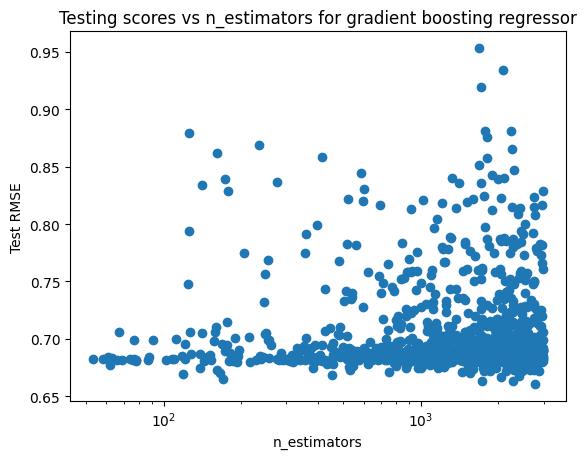

In [53]:
ccp_alphas = rsh.cv_results_["param_n_estimators"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("n_estimators")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs n_estimators for gradient boosting regressor")
plt.show()

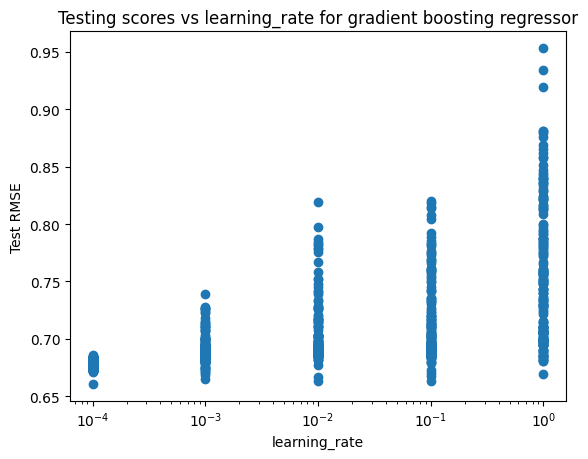

In [54]:
ccp_alphas = rsh.cv_results_["param_learning_rate"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("learning_rate")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs learning_rate for gradient boosting regressor")
plt.show()

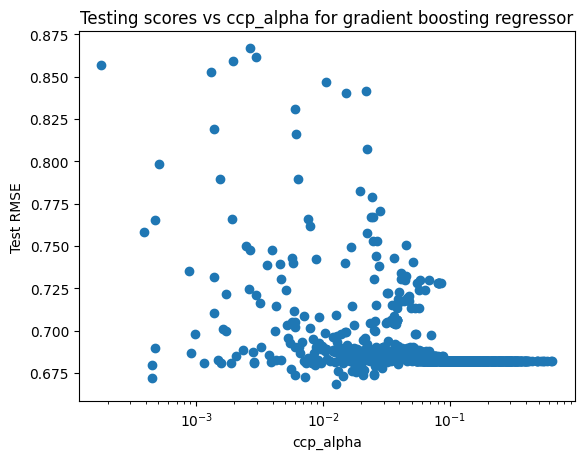

In [69]:
ccp_alphas = rsh.cv_results_["param_ccp_alpha"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("ccp_alpha")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs ccp_alpha for gradient boosting regressor")
plt.show()

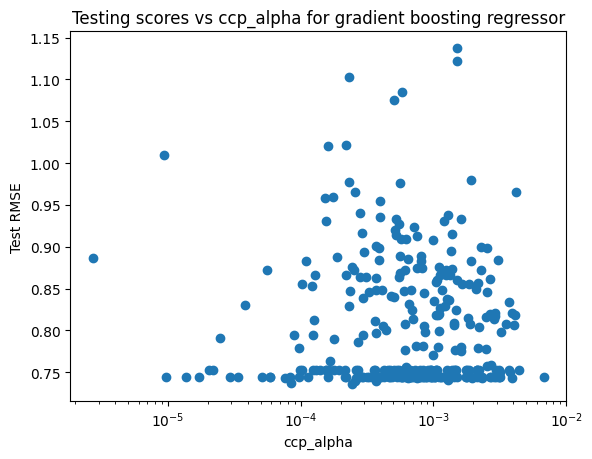

In [34]:
ccp_alphas = rsh.cv_results_["param_ccp_alpha"].data
test_scores = -rsh.cv_results_["mean_test_score"]

# Plot the testing scores vs ccp_alpha
plt.figure()
plt.semilogx(ccp_alphas, test_scores, marker="o",linewidth=0)
#plt.plot(ccp_alphas, test_scores, marker="o",linewidth=0)
plt.xlabel("ccp_alpha")
plt.ylabel("Test RMSE")
plt.title("Testing scores vs ccp_alpha for gradient boosting regressor")
plt.show()

/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 40.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 44.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: UserWarning: 33.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/shic892/.local/lib/python3.7/site-packages/seaborn/categorical.py:3543: Us

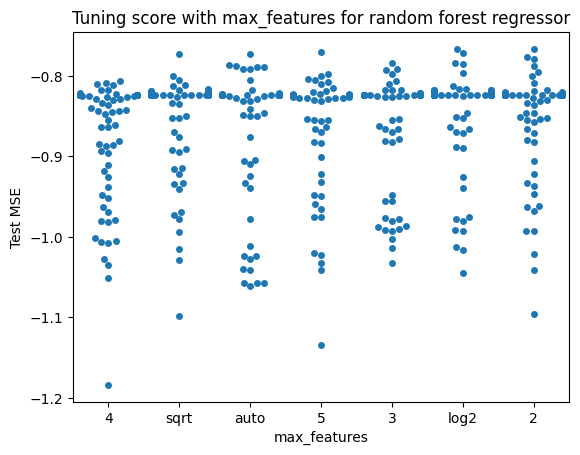

In [21]:
import seaborn as sns 

results_df = pd.DataFrame(rsh.cv_results_)
sns.swarmplot(x="param_max_features", y="mean_test_score", data=results_df)
plt.xlabel("max_features")
plt.ylabel("Test MSE")
plt.title("Tuning score with max_features for random forest regressor")
plt.show()